<a href="https://colab.research.google.com/github/johnjoseph004/AI-ML-internship/blob/main/DAY5_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [63]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize,sent_tokenize
from nltk.stem import WordNetLemmatizer
df=pd.read_csv("/content/chinese_english_pinyin_hsk.csv")
df

,Unnamed: 0,english,hsk,mandarin,pinyin
0,0,She wears a shawl with a mink,1,她戴着带有貂皮的披肩,tā dài zhuó dài yǒu diāo pí de pī jiān。
1,1,"`Abracadabra,' said the conjuror as he pulled ...",1,"魔术师口中念念有词, 把兔子从礼帽中掏了出来.","mó shù shī kǒu zhòng niàn niàn yǒu cí, bǎ tù ..."
2,2,20 jin goes to 10 kilograms.,1,二十市斤折合十公斤。,èr shí shì jīn zhé hé shí gōng jīn。
3,3,A balcony is a platform with a wall.,1,阳台是有墙的平台。,yáng tái shì yǒu qiáng de píng tái。
4,4,A belt of trees grew between the two fields.,1,两块田之间有一条树木带。,liǎng kuài tián zhī jiān yǒu yī tiáo shù mù dài。
...,...,...,...,...,...
22359,22359,"The capital of Wisconsin, in the south-central...",4,麦迪逊美国威斯康星州首府，位于该州的中南部，密尔沃基的西边。它于1836年被选定作为该州的首...,mài dí xùn Měi guó wēi sī kāng xīng zhōu shǒu ...
22360,22360,"The capital of Wisconsin, in the south-central...",4,麦迪逊美国威斯康星州首府，位于该州的中南部，密尔沃基的西边。它于1836年被选定作为该州的首...,mài dí xùn Měi guó wēi sī kāng xīng zhōu shǒu ...
22361,22361,What parents don't understand is that fat prov...,4,"父母们所了不解的是，脂肪提供非常宝贵的热量，并且每个细胞都需要脂肪和胆固醇才能生长，她说。""...",fù mǔ men suǒ le bù jiě de shì， zhī fáng tí gō...
22362,22362,"Any solution [to Soviet economic malaise], how...",4,不过，任何解决[苏联经济失调]办的法都受到权力危机的影响，在改革与开放，经济与政治之间产生一...,bù guò， rèn hé jiě jué[ sū lián jīng jì shī ti...


In [64]:
df['english'].to_csv('english_cleaned.csv', index=False, header=True)
print("The 'english' column has been successfully exported to 'english_cleaned.csv'")

The 'english' column has been successfully exported to 'english_cleaned.csv'


In [65]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize,sent_tokenize
from nltk.stem import WordNetLemmatizer
df=pd.read_csv("/content/english_cleaned.csv")
df.head(5)

,english
0,She wears a shawl with a mink
1,"`Abracadabra,' said the conjuror as he pulled ..."
2,20 jin goes to 10 kilograms.
3,A balcony is a platform with a wall.
4,A belt of trees grew between the two fields.


In [66]:
df['english_lower'] = df['english'].astype(str).str.lower()
display(df[['english', 'english_lower']].head())

,english,english_lower
0,She wears a shawl with a mink,she wears a shawl with a mink
1,"`Abracadabra,' said the conjuror as he pulled ...","`abracadabra,' said the conjuror as he pulled ..."
2,20 jin goes to 10 kilograms.,20 jin goes to 10 kilograms.
3,A balcony is a platform with a wall.,a balcony is a platform with a wall.
4,A belt of trees grew between the two fields.,a belt of trees grew between the two fields.


In [67]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [68]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [69]:
df['english_tokens'] = df['english_lower'].apply(word_tokenize)
display(df[['english_lower', 'english_tokens']].head(5))

,english_lower,english_tokens
0,she wears a shawl with a mink,"[she, wears, a, shawl, with, a, mink]"
1,"`abracadabra,' said the conjuror as he pulled ...","[`, abracadabra, ,, ', said, the, conjuror, as..."
2,20 jin goes to 10 kilograms.,"[20, jin, goes, to, 10, kilograms, .]"
3,a balcony is a platform with a wall.,"[a, balcony, is, a, platform, with, a, wall, .]"
4,a belt of trees grew between the two fields.,"[a, belt, of, trees, grew, between, the, two, ..."


In [70]:
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [word for word in tokens if word.lower() not in stop_words]

df['english_filtered_tokens'] = df['english_tokens'].apply(remove_stopwords)
display(df[['english_tokens', 'english_filtered_tokens']].head(5))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,english_tokens,english_filtered_tokens
0,"[she, wears, a, shawl, with, a, mink]","[wears, shawl, mink]"
1,"[`, abracadabra, ,, ', said, the, conjuror, as...","[`, abracadabra, ,, ', said, conjuror, pulled,..."
2,"[20, jin, goes, to, 10, kilograms, .]","[20, jin, goes, 10, kilograms, .]"
3,"[a, balcony, is, a, platform, with, a, wall, .]","[balcony, platform, wall, .]"
4,"[a, belt, of, trees, grew, between, the, two, ...","[belt, trees, grew, two, fields, .]"


In [71]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

def stem_tokens(tokens):
    return [stemmer.stem(word) for word in tokens]

df['english_stemmed_tokens'] = df['english_filtered_tokens'].apply(stem_tokens)
display(df[['english_filtered_tokens', 'english_stemmed_tokens']].head(10))

,english_filtered_tokens,english_stemmed_tokens
0,"[wears, shawl, mink]","[wear, shawl, mink]"
1,"[`, abracadabra, ,, ', said, conjuror, pulled,...","[`, abracadabra, ,, ', said, conjuror, pull, r..."
2,"[20, jin, goes, 10, kilograms, .]","[20, jin, goe, 10, kilogram, .]"
3,"[balcony, platform, wall, .]","[balconi, platform, wall, .]"
4,"[belt, trees, grew, two, fields, .]","[belt, tree, grew, two, field, .]"
5,"[black, swan, rare, .]","[black, swan, rare, .]"
6,"[breeder, means, person, breeds, animals, .]","[breeder, mean, person, breed, anim, .]"
7,"[cab, ten, minutes, .]","[cab, ten, minut, .]"
8,"[cadre, must, reach, one, masses, .]","[cadr, must, reach, one, mass, .]"
9,"[canyon, usually, river, flowing, .]","[canyon, usual, river, flow, .]"


In [72]:
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [73]:
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df['english_lemmatized_tokens'] = df['english_filtered_tokens'].apply(lemmatize_tokens)

In [74]:
display(df[['english_filtered_tokens', 'english_stemmed_tokens', 'english_lemmatized_tokens']].head(10))

,english_filtered_tokens,english_stemmed_tokens,english_lemmatized_tokens
0,"[wears, shawl, mink]","[wear, shawl, mink]","[wear, shawl, mink]"
1,"[`, abracadabra, ,, ', said, conjuror, pulled,...","[`, abracadabra, ,, ', said, conjuror, pull, r...","[`, abracadabra, ,, ', said, conjuror, pulled,..."
2,"[20, jin, goes, 10, kilograms, .]","[20, jin, goe, 10, kilogram, .]","[20, jin, go, 10, kilogram, .]"
3,"[balcony, platform, wall, .]","[balconi, platform, wall, .]","[balcony, platform, wall, .]"
4,"[belt, trees, grew, two, fields, .]","[belt, tree, grew, two, field, .]","[belt, tree, grew, two, field, .]"
5,"[black, swan, rare, .]","[black, swan, rare, .]","[black, swan, rare, .]"
6,"[breeder, means, person, breeds, animals, .]","[breeder, mean, person, breed, anim, .]","[breeder, mean, person, breed, animal, .]"
7,"[cab, ten, minutes, .]","[cab, ten, minut, .]","[cab, ten, minute, .]"
8,"[cadre, must, reach, one, masses, .]","[cadr, must, reach, one, mass, .]","[cadre, must, reach, one, mass, .]"
9,"[canyon, usually, river, flowing, .]","[canyon, usual, river, flow, .]","[canyon, usually, river, flowing, .]"


In [75]:
from sklearn.feature_extraction.text import CountVectorizer

df['english_filtered_text'] = df['english_filtered_tokens'].apply(lambda x: ' '.join(x))

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(df['english_filtered_text'])

In [76]:
print("Vocabulary (first 20 words):")
print(vectorizer.vocabulary_)

print("\nFeature Names (first 20 words):")
print(vectorizer.get_feature_names_out()[:20])

print("\nSparse Matrix (first 5 rows, showing non-zero counts):")
print(X[:5])

print("\nShape of the feature matrix:")
print(X.shape)

Vocabulary (first 20 words):
{'wears': 16148, 'shawl': 13239, 'mink': 9281, 'abracadabra': 194, 'said': 12761, 'conjuror': 3142, 'pulled': 11582, 'rabbit': 11754, 'hat': 6877, '20': 71, 'jin': 8075, 'goes': 6510, '10': 7, 'kilograms': 8204, 'balcony': 1268, 'platform': 10891, 'wall': 16033, 'belt': 1490, 'trees': 15300, 'grew': 6649, 'two': 15460, 'fields': 5710, 'black': 1606, 'swan': 14558, 'rare': 11856, 'breeder': 1882, 'means': 9063, 'person': 10667, 'breeds': 1884, 'animals': 723, 'cab': 2106, 'ten': 14811, 'minutes': 9291, 'cadre': 2116, 'must': 9575, 'reach': 11892, 'one': 10052, 'masses': 9003, 'canyon': 2197, 'usually': 15745, 'river': 12560, 'flowing': 5916, 'chance': 2402, 'meeting': 9103, 'brought': 1955, 'old': 10035, 'friends': 6171, 'together': 15075, 'cloud': 2735, 'mass': 9000, 'vapor': 15792, 'sky': 13520, 'coal': 2760, 'fell': 5653, 'fire': 5774, 'burned': 2044, 'mat': 9013, 'collector': 2827, 'insects': 7739, 'show': 13333, 'us': 15730, 'latest': 8362, 'discoveries

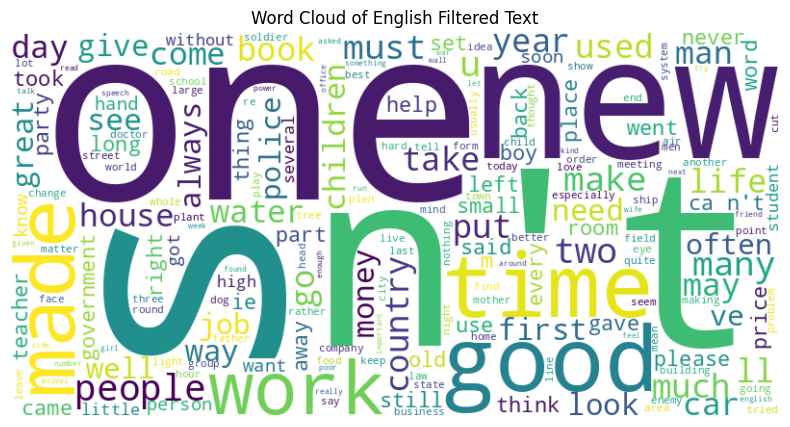

In [77]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_words = ' '.join([text for text in df['english_filtered_text']])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of English Filtered Text')
plt.show()